In [1]:
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.data import random_split

from torchvision import datasets
import torchvision.transforms as transforms

import torch.optim as optim

import matplotlib.pyplot as plt

In [2]:
batch_size = 128
# batch_size = 25


Loads the test_val_datset, and the test_dataset. This will take a couple of minutes to load

In [ ]:

#Transform is used for CNN
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

training_data = datasets.CIFAR10(
    root= "data", 
    train = True,
    download=True,
    transform=transform
)

testing_data = datasets.CIFAR10(
    root= "data", 
    train = False,
    download=True,
    transform=transform
)



100.0%


Splitting the training data into to train_dataset and a validation_dataset

In [4]:
train_val_amt = int(len(training_data) * 0.75)
validation_set = int(len(training_data) - train_val_amt)

print(train_val_amt, validation_set)

train_dataset, validation_dataset = random_split(training_data, [train_val_amt, validation_set], generator=torch.Generator().manual_seed(1234))

37500 12500


In [5]:
train_data_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
validation_data_loader = DataLoader(validation_dataset, batch_size = batch_size, shuffle = True)
testing_data_loader = DataLoader(testing_data, batch_size = batch_size, shuffle = True)

Prints the dataset numbers and percentage of training and validation data.

In [6]:
print(f"Training Data Total: {len(train_dataset)}, {len(train_dataset) / (len(train_dataset) + len(validation_dataset))}")
print(f"Validation Data Total: {len(validation_dataset)}, {len(validation_dataset) / (len(train_dataset) + len(validation_dataset))}")
print(f"Testing Data total:", len(testing_data))


Training Data Total: 37500, 0.75
Validation Data Total: 12500, 0.25
Testing Data total: 10000


tensor([[[1.0000, 1.0000, 1.0000],
         [1.0000, 0.9961, 1.0000],
         [1.0000, 1.0000, 0.9922],
         ...,
         [1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000]],

        [[1.0000, 1.0000, 1.0000],
         [1.0000, 0.9961, 1.0000],
         [1.0000, 1.0000, 0.9922],
         ...,
         [1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000]],

        [[1.0000, 1.0000, 1.0000],
         [0.9961, 0.9961, 0.9961],
         [0.9922, 0.9961, 0.9961],
         ...,
         [1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000]],

        ...,

        [[1.0000, 1.0000, 0.9961],
         [0.9922, 0.9922, 1.0000],
         [0.9882, 0.9843, 0.9961],
         ...,
         [1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000]],

        [[0.9961, 0.9961, 0.9922],
         [0.9922, 0.9882, 0.9961],
         [1.

Text(0.5, 1.0, 'Ship')

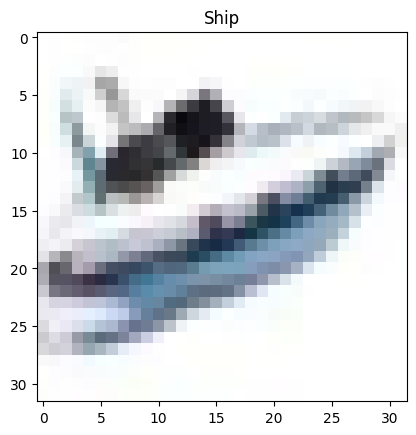

In [7]:
classes = ["Airplane", "Automobile", "Bird", "Cat", "Deer", "Dog", "Frog", "Horse", "Ship", "Truck"]
training_iter = iter(train_data_loader)

data_obj, label = next(training_iter)
data_obj = data_obj[0]
data_obj = data_obj * 0.5 + 0.5
label = label[0]
data_obj = data_obj.permute(1, 2, 0)
print(data_obj, label)
plt.imshow(data_obj)
plt.title(f"{classes[label]}")

In [9]:
class ConvNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        #Input is 32 x 32 pixels, 3 channels
        self.conv1Net = nn.Conv2d(3, 3, 5)
        # Output is 3, 28 x 28 matrices
        self.maxPool2D1 = nn.MaxPool2d(2,2)
        # Output is 3, 14 x 14 matrices
        self.conv2Net = nn.Conv2d(3, 18, 3)
        # Output is 18, 12 x 12 matrices
        self.maxPool2D2 = nn.MaxPool2d(2,2)
        # Output is 18, 6 x 6 matrices
        self.lin = nn.Linear(18 * 6 * 6, 10)

    def forward(self, x):
        x = self.maxPool2D1(F.relu(self.conv1Net(x)))
        x = self.maxPool2D2(F.relu(self.conv2Net(x)))
        x = self.lin(torch.flatten(x, 1))
        return x



In [14]:
class FeedForwardNN(nn.Module):
    def __init__(self, input_size=3*32*32, hidden1=1024, hidden2=512, num_classes=10):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, num_classes)

    def forward(self, x):
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [15]:
# Train FeedForwardNN
ff_model = FeedForwardNN()
ff_criterion = nn.CrossEntropyLoss()
ff_optimizer = optim.SGD(ff_model.parameters(), lr=0.001)

ff_max_epoch = 100  # you can increase this

for epoch in range(ff_max_epoch):
    running_loss = 0.0
    for inputs, labels in train_data_loader:
        ff_optimizer.zero_grad()

        outputs = ff_model(inputs)
        loss = ff_criterion(outputs, labels)
        loss.backward()
        ff_optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch + 1}/{ff_max_epoch}, Loss: {running_loss/len(train_data_loader):.4f}")

Epoch 1/100, Loss: 2.2929
Epoch 2/100, Loss: 2.2682
Epoch 3/100, Loss: 2.2430
Epoch 4/100, Loss: 2.2165
Epoch 5/100, Loss: 2.1888
Epoch 6/100, Loss: 2.1611
Epoch 7/100, Loss: 2.1343
Epoch 8/100, Loss: 2.1092
Epoch 9/100, Loss: 2.0855
Epoch 10/100, Loss: 2.0632
Epoch 11/100, Loss: 2.0420
Epoch 12/100, Loss: 2.0218
Epoch 13/100, Loss: 2.0026
Epoch 14/100, Loss: 1.9843
Epoch 15/100, Loss: 1.9670
Epoch 16/100, Loss: 1.9507
Epoch 17/100, Loss: 1.9353
Epoch 18/100, Loss: 1.9207
Epoch 19/100, Loss: 1.9070
Epoch 20/100, Loss: 1.8941
Epoch 21/100, Loss: 1.8818
Epoch 22/100, Loss: 1.8703
Epoch 23/100, Loss: 1.8593
Epoch 24/100, Loss: 1.8489
Epoch 25/100, Loss: 1.8391
Epoch 26/100, Loss: 1.8296
Epoch 27/100, Loss: 1.8206
Epoch 28/100, Loss: 1.8120
Epoch 29/100, Loss: 1.8036
Epoch 30/100, Loss: 1.7956
Epoch 31/100, Loss: 1.7878
Epoch 32/100, Loss: 1.7803
Epoch 33/100, Loss: 1.7730
Epoch 34/100, Loss: 1.7659
Epoch 35/100, Loss: 1.7590
Epoch 36/100, Loss: 1.7522
Epoch 37/100, Loss: 1.7455
Epoch 38/1

In [16]:
# Evaluate FeedForwardNN on test set
ff_model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in testing_data_loader:
        outputs = ff_model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"FeedForwardNN Test Accuracy: {100 * correct / total:.2f}% ({correct}/{total})")

FeedForwardNN Test Accuracy: 47.15% (4715/10000)


In [134]:
CNN = ConvNeuralNetwork()

criteriorn = nn.CrossEntropyLoss()
optimizer = optim.SGD(CNN.parameters(), lr = 0.001)

In [135]:
max_epoch = 2
# max_epoch = 10

for epoch in range(max_epoch):
    run_loss = 0
    for data in train_data_loader:
        inputs, labels = data

        optimizer.zero_grad()

        output = CNN(inputs)
        loss = criteriorn(output, labels)
        loss.backward()
        optimizer.step()

        run_loss += loss.item()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9529412..0.96862745].


tensor([8])
tensor([[[0.1451, 0.2118, 0.0706],
         [0.0706, 0.1176, 0.0314],
         [0.1294, 0.0824, 0.0275],
         ...,
         [0.1922, 0.1686, 0.0980],
         [0.2275, 0.1922, 0.1137],
         [0.2392, 0.1922, 0.1020]],

        [[0.1373, 0.1686, 0.0588],
         [0.0353, 0.0745, 0.0039],
         [0.0588, 0.0510, 0.0078],
         ...,
         [0.1961, 0.1608, 0.0941],
         [0.2196, 0.1765, 0.0980],
         [0.2235, 0.1725, 0.0863]],

        [[0.1843, 0.1922, 0.0941],
         [0.0627, 0.0980, 0.0196],
         [0.0588, 0.0863, 0.0275],
         ...,
         [0.2275, 0.1843, 0.1216],
         [0.2275, 0.1686, 0.0941],
         [0.2667, 0.2039, 0.1255]],

        ...,

        [[0.2549, 0.2157, 0.1451],
         [0.2667, 0.1922, 0.1216],
         [0.2980, 0.1961, 0.1216],
         ...,
         [0.4392, 0.3490, 0.2863],
         [0.4471, 0.3569, 0.2941],
         [0.4510, 0.3569, 0.2941]],

        [[0.2863, 0.2353, 0.1490],
         [0.3882, 0.2824, 0.1922],


Text(0.5, 1.0, 'Actual: Truck Predicted: Ship')

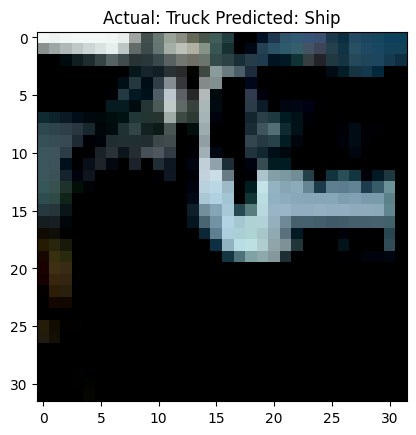

In [141]:
validation_iter = iter(validation_data_loader)

data_obj_te, label_te = next(validation_iter)
data_obj_te = data_obj_te[0]

data_obj_unorm = data_obj_te * 0.5 + 0.5
label_te = label_te[0]
data_obj_im = data_obj_te.permute(1, 2, 0)

output = CNN(data_obj_te.unsqueeze(0))
_, predicted = torch.max(output.data, 1)

print(predicted)
print(data_obj, label)
plt.imshow(data_obj_im)
plt.title(f"Actual: {classes[label_te]} Predicted: {classes[predicted]}")


Evaluating Accuracy of Convolutional Model

In [ ]:
# total = len(testing_data)
append_data = True
total = 15
correct = 0
current = 0
if total > 20:
    append_data = False

real_labels = []
predicted_labels = [] 
#check


testing_iters = iter(validation_data_loader)
with torch.no_grad():
    for images in testing_iters:
        if current >= total: break
        current += 1
        data_obj_te, label_te = images
        data_obj_te = data_obj_te[0]

        data_obj_unorm = data_obj_te * 0.5 + 0.5
        label_te = label_te[0]
        data_obj_im = data_obj_te.permute(1, 2, 0)

        output = CNN(data_obj_te.unsqueeze(0))
        _, predicted = torch.max(output.data, 1)
        if (classes[label_te] == classes[predicted]):
            correct += 1
        if append_data:
            real_labels.append(classes[label_te])
            predicted_labels.append(classes[predicted])
print(correct)
print(real_labels)
print(predicted_labels)
print("Error Rate is", 1 - (correct / total))

2
['Deer', 'Ship', 'Dog', 'Horse', 'Airplane', 'Horse', 'Cat', 'Bird', 'Ship', 'Truck', 'Deer', 'Dog', 'Truck', 'Horse', 'Cat']
['Cat', 'Ship', 'Horse', 'Cat', 'Airplane', 'Ship', 'Ship', 'Horse', 'Airplane', 'Ship', 'Horse', 'Horse', 'Frog', 'Ship', 'Horse']
Error Rate is 0.8666666666666667


# kNN Classifier


In [ ]:
class kNNClassifier:
    def __init__(self, k_value = 1):
        self._k = k_value
        self._X_train = []
        self._y_train = []

    def fit(self, training_data):
        '''Stores the X_tr and y_tr values to be used for predictions'''

        # Separate DataLoader into X and y values
        for batch_features, batch_labels in training_data:
            self._X_train.append(batch_features)
            self._y_train.append(batch_labels)

        self._X_train = torch.cat(self._X_train, dim=0)
        self._y_train = torch.cat(self._y_train, dim=0)

    def predict(self, X: DataLoader):
        '''Based on stored X_train and y_train values, makes a prediction for the class labels of the given X'''

        X_inputs = []
        for batch_features, batch_labels in X:
            X_inputs.append(batch_features)

        X_inputs = torch.cat(X_inputs, dim=0)

        n_inputs = X_inputs.shape[0]
        n_train = self._X_train.shape[0]
        X_inputs_flat = X_inputs.view(n_inputs, -1)
        X_train_flat = self._X_train.view(n_train, -1)

        # For A training points and B testing, returns A x B tensor
        distances = torch.cdist(X_train_flat, X_inputs_flat)
        distances = distances.t()

        # Finds k-nearest neighbors by the ones with the smallest distances
        kNN_indices = torch.topk(distances, self._k, largest=False, dim=1).indices

        kNN_labels = self._y_train[kNN_indices]

        predictions = torch.mode(kNN_labels, dim=1).values
        return predictions


In [ ]:
# Shuffle MUST be false or else I can't determine accuracy (the results are in a different order from the datapoints)
train_data = DataLoader(train_dataset, batch_size = batch_size, shuffle = False)
validation_data = DataLoader(validation_dataset, batch_size = batch_size, shuffle = False)

# k = 3 kNN Classifier 
kNN = kNNClassifier(3)
kNN.fit(train_data)
y_hat_3 = kNN.predict(train_data)

In [ ]:
# Simple test to see if it's working, looking at the predictions
features, labels = next(iter(train_data))
for i in range(len(features)):
    print(f'This is the true label: {labels[i]}')
    print(y_hat_3[i])

This is the true label: 8
tensor(8)
This is the true label: 6
tensor(6)
This is the true label: 6
tensor(4)
This is the true label: 1
tensor(1)
This is the true label: 7
tensor(3)
This is the true label: 7
tensor(4)
This is the true label: 3
tensor(0)
This is the true label: 5
tensor(5)
This is the true label: 0
tensor(0)
This is the true label: 5
tensor(2)
This is the true label: 0
tensor(0)
This is the true label: 8
tensor(8)
This is the true label: 5
tensor(2)
This is the true label: 0
tensor(0)
This is the true label: 2
tensor(2)
This is the true label: 4
tensor(0)
This is the true label: 0
tensor(8)
This is the true label: 6
tensor(6)
This is the true label: 3
tensor(2)
This is the true label: 0
tensor(0)
This is the true label: 4
tensor(4)
This is the true label: 2
tensor(2)
This is the true label: 5
tensor(2)
This is the true label: 2
tensor(2)
This is the true label: 4
tensor(4)
This is the true label: 6
tensor(6)
This is the true label: 5
tensor(5)
This is the true label: 9
te

In [ ]:
# Test with k = 1 to see if training accuracy is 100% 
kNN = kNNClassifier(1)
kNN.fit(train_data)
y_hat_1 = kNN.predict(train_data)


In [ ]:
# Accuracy function to visualize error rates for different k values, to select hyperparameter
# Splits up training data to get all true y values

def accuracy_score(true_values, y_pred):
    y_true = []
    for _, batch_labels in true_values:
            y_true.append(batch_labels)

    y_true = torch.cat(y_true, dim=0)

    correct = 0
    for i in range(len(y_pred)):
        if y_true[i] == y_pred[i]:
            correct += 1
    
    return correct / len(y_true)

accuracy_score(train_data, y_hat_1)

1.0

In [ ]:
# Testing out k-values of [1, 3, 5, 10, 15, 20, 50]
k_values = [1, 3, 5, 10, 15, 20, 50]

def kNN_accuracy(k_value: int, training_data: DataLoader, validation_data: DataLoader):
    kNN = kNNClassifier(k_value)
    kNN.fit(training_data)

    tr_pred = kNN.predict(training_data)
    te_pred = kNN.predict(validation_data)

    tr_acc = accuracy_score(training_data, tr_pred)
    te_acc = accuracy_score(validation_data, te_pred)

    return tr_acc, te_acc

training_accuracies = []
testing_accuracies = []
for k_value in k_values:    
    accs = kNN_accuracy(k_value, train_data, validation_data)
    training_accuracies.append(accs[0])
    testing_accuracies.append(accs[1])

In [ ]:
print(training_accuracies)
print(testing_accuracies)

[1.0, 0.5687733333333334, 0.4926933333333333, 0.42090666666666665, 0.39016, 0.37096, 0.33010666666666666]
[0.34096, 0.32368, 0.33128, 0.3288, 0.32536, 0.32312, 0.31088]


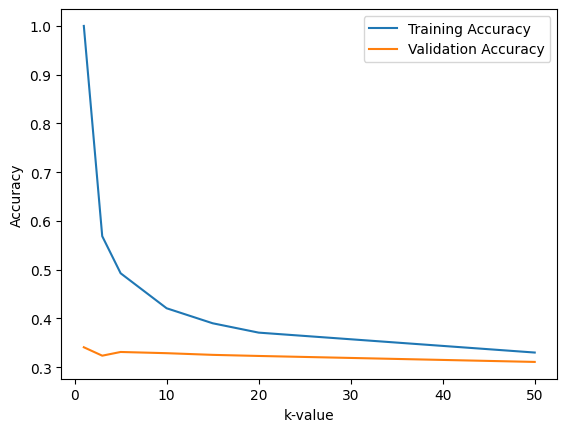

In [ ]:
# Plotting the training/testing accuracy as a function of k-value, with full training data size of 37500 used

plt.plot(k_values, training_accuracies, label = 'Training Accuracy')
plt.plot(k_values, testing_accuracies, label = 'Validation Accuracy')
plt.legend()
plt.xlabel('k-value')
plt.ylabel('Accuracy')
plt.show()

kNN models can benefit from training on a smaller subset of the data rather than the entire set of 37500. Based on the previous trials, the optimal value of k is 1. 

Computing learning curves on kNN with k = 1 to find the optimal training data size.

In [ ]:
# Create a smaller, random subset of the train dataset and find its training and validation accuracy
subset_sizes = [1000, 5000, 10000, 15000, 20000, 25000, 30000, 35000, 37500]

def subset_kNN_accuracy(subset_size: int):
    indices = torch.randperm(len(train_dataset))[:subset_size]
    subset = Subset(train_dataset, indices)
    subset_loader = DataLoader(subset, batch_size = 100, shuffle = False)

    return kNN_accuracy(1, subset_loader, validation_data)

In [ ]:
# Loop through the subset_sizes to gather data

tr_acc_ss = []
te_acc_ss = []

for subset_size in subset_sizes:
    accuracies = subset_kNN_accuracy(subset_size)
    tr_acc_ss.append(accuracies[0])
    te_acc_ss.append(accuracies[1])

In [ ]:
print(tr_acc_ss)
print(te_acc_ss)

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[0.23664, 0.2704, 0.29064, 0.30336, 0.31464, 0.32352, 0.33344, 0.33984, 0.34096]


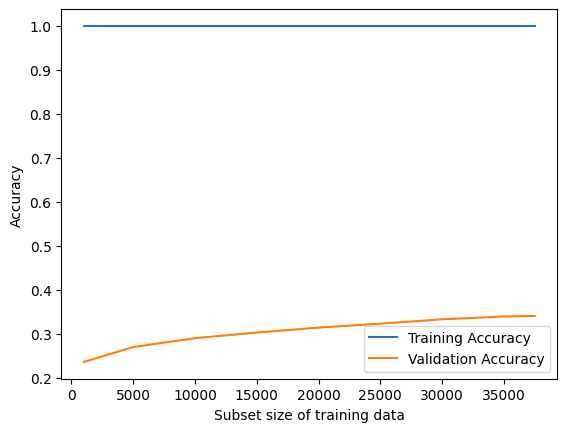

In [ ]:
# Plot the resulting training and testing accuracies as a function of subset size

plt.plot(subset_sizes, tr_acc_ss, label = 'Training Accuracy')
plt.plot(subset_sizes, te_acc_ss, label = 'Validation Accuracy')
plt.legend()
plt.xlabel('Subset size of training data')
plt.ylabel('Accuracy')
plt.show()

Optimal k-value = 1, optimal training data size is the full set, 37500. Note that I did try other k-values with the differing subsets (3, 5, 10, 20), but all of them yielded lower final validation accuracy values.